# **Modeling**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')


## **3.0 Prepare the dataset**

In [2]:

# Load data
X_train = pd.read_csv('X_train.csv')
X_val = pd.read_csv('X_val.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_val = pd.read_csv('y_val.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()



In [3]:
# Encode target labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)
num_classes = len(le.classes_)

In [4]:

# For one-hot in loss function
y_train_cat = keras.utils.to_categorical(y_train_enc, num_classes)
y_val_cat = keras.utils.to_categorical(y_val_enc, num_classes)
y_test_cat = keras.utils.to_categorical(y_test_enc, num_classes)

print("Train shape:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Number of classes:", num_classes)

Train shape: (4182, 133) Val: (738, 133) Test: (42, 133)
Number of classes: 41


## **3.1 Deep MLP**

In [5]:
def build_mlp(input_dim, num_classes):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    # First hidden block
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))
    
    # Second block
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))
    
    # Third block
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))
    
    # Fourth block
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))
    
    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))
    
    return model

model = build_mlp(X_train.shape[1], num_classes)
model.summary()

2026-06-20 17:47:55.037010: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        34,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 41)             │         1,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,809 (315.66 KB)

 Trainable params: 79,849 (311.91 KB)

 Non-trainable params: 960 (3.75 KB)

### **3.1.1 Compile and train**

In [6]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
checkpoint = callbacks.ModelCheckpoint('best_mlp_model.h5', 
                                       save_best_only=True, 
                                       monitor='val_accuracy', 
                                       mode='max')
early_stop = callbacks.EarlyStopping(patience=15, 
                                     restore_best_weights=True, 
                                     monitor='val_loss')
reduce_lr = callbacks.ReduceLROnPlateau(factor=0.5, patience=5, 
                                        min_lr=1e-6, monitor='val_loss')

history = model.fit(X_train, y_train_cat,
                    validation_data=(X_val, y_val_cat),
                    epochs=150,
                    batch_size=64,
                    callbacks=[checkpoint, early_stop, reduce_lr],
                    verbose=1)


Epoch 1/150
59/66 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1288 - loss: 3.4663

66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.2776 - loss: 2.8368 - val_accuracy: 0.2629 - val_loss: 3.2030 - learning_rate: 0.0010
Epoch 2/150
62/66 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6122 - loss: 1.8547

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6882 - loss: 1.6416 - val_accuracy: 0.9566 - val_loss: 2.0432 - learning_rate: 0.0010
Epoch 3/150
63/66 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8245 - loss: 1.1740

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8549 - loss: 1.0666 - val_accuracy: 1.0000 - val_loss: 0.9684 - learning_rate: 0.0010
Epoch 4/150
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9216 - loss: 0.7261 - val_accuracy: 0.9959 - val_loss: 0.3685 - learning_rate: 0.0010
Epoch 5/150
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9550 - loss: 0.5151 - val_accuracy: 0.9973 - val_loss: 0.1354 - learning_rate: 0.0010
Epoch 6/150
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9665 - loss: 0.3801 - val_accuracy: 1.0000 - val_loss: 0.0497 - learning_rate: 0.0010
Epoch 7/150
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9715 - loss: 0.2961 - val_accuracy: 1.0000 - val_loss: 0.0237 - learning_rate: 0.0010
Epoch 8/150
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9830 - loss: 0.2311 - val_accuracy: 1.0000 - val_loss: 0.0119 - learning_rate: 0.0010
Epoch 9/150
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9828 - loss: 0.1924 - val_accuracy

In [7]:
# Load best model (saved by checkpoint)
model = models.load_model('best_mlp_model.h5')


### **3.1.2 Evaluate on test set**

In [8]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Metrics
accuracy = accuracy_score(y_test_enc, y_pred)
precision_macro = precision_score(y_test_enc, y_pred, average='macro')
precision_weighted = precision_score(y_test_enc, y_pred, average='weighted')
recall_macro = recall_score(y_test_enc, y_pred, average='macro')
recall_weighted = recall_score(y_test_enc, y_pred, average='weighted')
f1_macro = f1_score(y_test_enc, y_pred, average='macro')
f1_weighted = f1_score(y_test_enc, y_pred, average='weighted')


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step


/mnt/hdisk/markov-consults/econia/.venvs20251212/lib/python3.12/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/mnt/hdisk/markov-consults/econia/.venvs20251212/lib/python3.12/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/mnt/hdisk/markov-consults/econia/.venvs20251212/lib/python3.12/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_tr

#### **3.1.2.1 AUC-ROC (macro) – one-vs-rest**

In [9]:
try:
    auc_macro = roc_auc_score(y_test_cat, y_pred_probs, multi_class='ovr', average='macro')
except:
    auc_macro = None

print("\n" + "="*60)
print("BASELINE MLP PERFORMANCE ON TEST SET")
print("="*60)
print(f"Accuracy:               {accuracy:.4f}")
print(f"Precision (macro):      {precision_macro:.4f}")
print(f"Precision (weighted):   {precision_weighted:.4f}")
print(f"Recall (macro):         {recall_macro:.4f}")
print(f"Recall (weighted):      {recall_weighted:.4f}")
print(f"F1-score (macro):       {f1_macro:.4f}")
print(f"F1-score (weighted):    {f1_weighted:.4f}")
if auc_macro:
    print(f"AUC-ROC (macro):        {auc_macro:.4f}")
print("="*60)

# Detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_, digits=4))


BASELINE MLP PERFORMANCE ON TEST SET
Accuracy:               0.9762
Precision (macro):      0.9878
Precision (weighted):   0.9881
Recall (macro):         0.9878
Recall (weighted):      0.9762
F1-score (macro):       0.9837
F1-score (weighted):    0.9762
AUC-ROC (macro):        0.9936

Classification Report:

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo     1.0000    1.0000    1.0000         1
                                   AIDS     1.0000    1.0000    1.0000         1
                                   Acne     1.0000    1.0000    1.0000         1
                    Alcoholic hepatitis     1.0000    1.0000    1.0000         1
                                Allergy     1.0000    1.0000    1.0000         1
                              Arthritis     1.0000    1.0000    1.0000         1
                       Bronchial Asthma     1.0000    1.0000    1.0000         1
                   Cervical spondylosis 

/mnt/hdisk/markov-consults/econia/.venvs20251212/lib/python3.12/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/mnt/hdisk/markov-consults/econia/.venvs20251212/lib/python3.12/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/mnt/hdisk/markov-consults/econia/.venvs20251212/lib/python3.12/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
/mnt/hdisk/m

#### **3.1.2.2  Plotting**

**Training history**

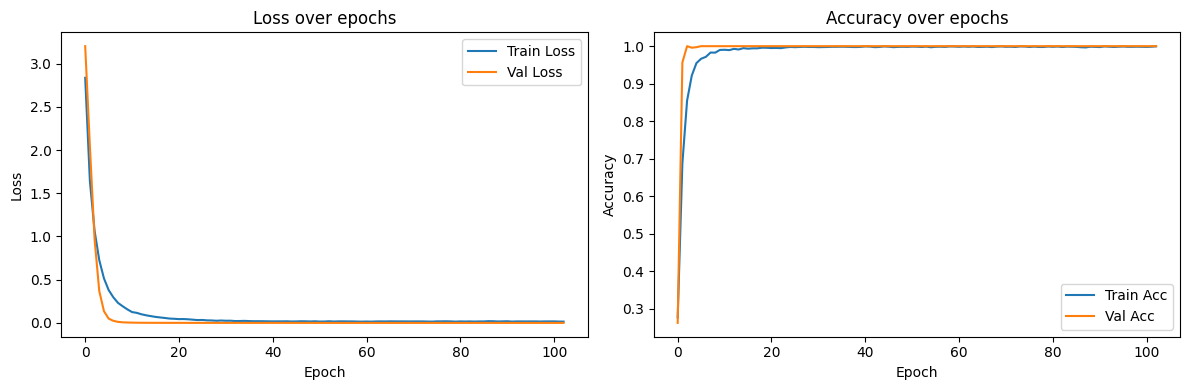

In [10]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_training_history.png')
plt.show()

**Confusion matrix**

/mnt/hdisk/markov-consults/econia/.venvs20251212/lib/python3.12/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/mnt/hdisk/markov-consults/econia/.venvs20251212/lib/python3.12/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/mnt/hdisk/markov-consults/econia/.venvs20251212/lib/python3.12/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
/mnt/hdisk/m

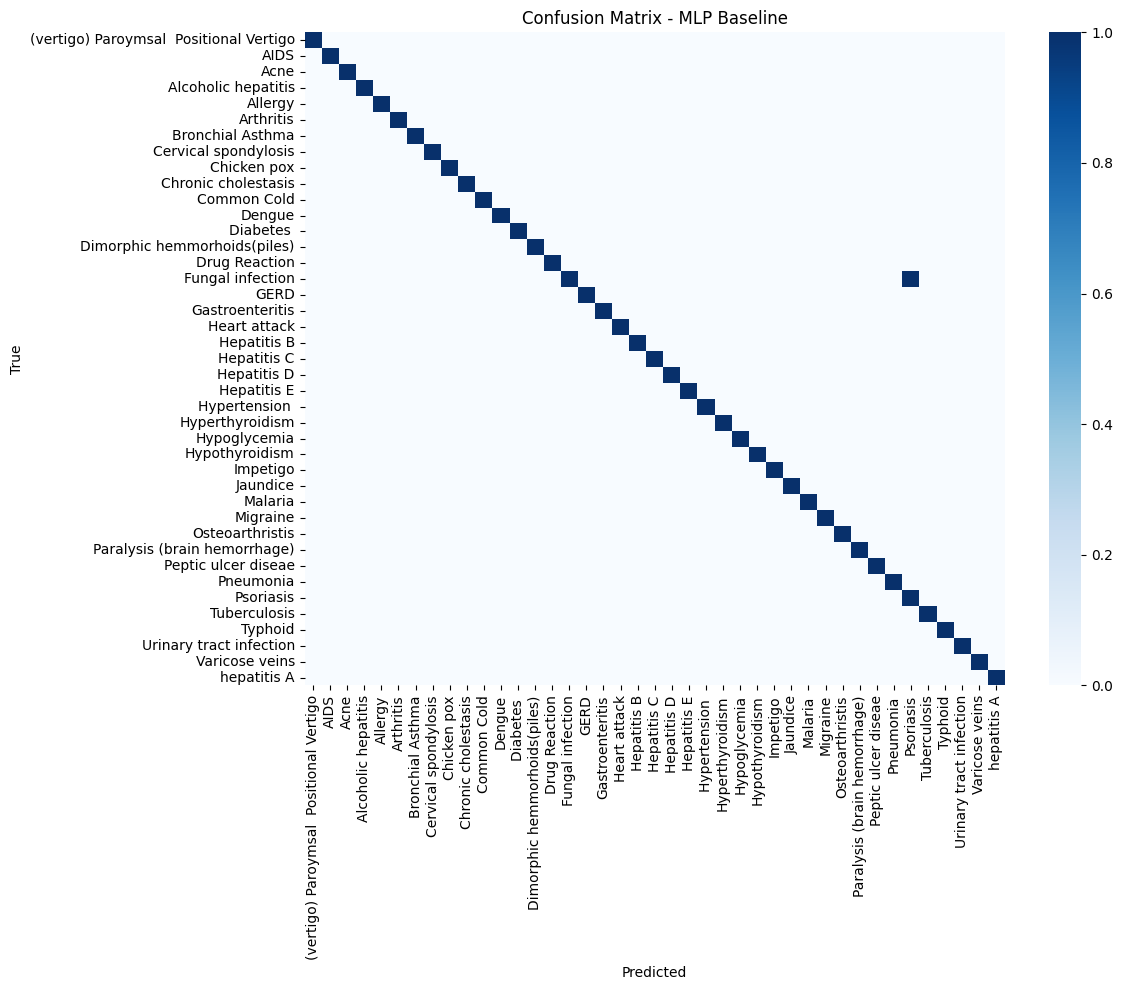


Sample Predictions (20 random test samples):
                True Disease            Predicted Disease
                        AIDS                         AIDS
     Urinary tract infection      Urinary tract infection
                 Hepatitis D                  Hepatitis D
                Heart attack                 Heart attack
                 hepatitis A                  hepatitis A
                 Common Cold                  Common Cold
                    Jaundice                     Jaundice
                        GERD                         GERD
                   Diabetes                     Diabetes 
            Bronchial Asthma             Bronchial Asthma
                Hypoglycemia                 Hypoglycemia
                     Typhoid                      Typhoid
         Chronic cholestasis          Chronic cholestasis
            Fungal infection             Fungal infection
                     Malaria                      Malaria
Dimorphic hemmorhoids(pile

In [11]:
cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - MLP Baseline')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('mlp_confusion_matrix.png')
plt.show()

# 5c. Example predictions (first 20 test samples)
sample_indices = np.random.choice(len(X_test), 20, replace=False)
sample_true = y_test.iloc[sample_indices].values
sample_pred = le.inverse_transform(y_pred[sample_indices])

comparison_df = pd.DataFrame({
    'True Disease': sample_true,
    'Predicted Disease': sample_pred
})
print("\nSample Predictions (20 random test samples):")
print(comparison_df.to_string(index=False))

#### **2.1.2.3 Save the model and label encoder for deployment**

In [12]:
# Model is already saved as 'best_mlp_model.h5'
# Save label encoder classes
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("\nModel and label encoder saved for deployment.")

# Also save feature columns order (important for inference)
feature_cols = X_train.columns.tolist()
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)
print("Feature columns saved.")


Model and label encoder saved for deployment.
Feature columns saved.


## **3.2 Comparative models**

DATA SHAPES (same as MLP)
Train: (4182, 133), Val: (738, 133), Test: (42, 133)
Test set contains 42 unique symptom-disease combinations.

Training Logistic Regression...
  ✓ Done. Test Accuracy: 0.9762

Training Random Forest...
  ✓ Done. Test Accuracy: 0.9762

Training XGBoost...
  ✓ Done. Test Accuracy: 0.9762

TRADITIONAL MODELS PERFORMANCE ON TEST SET (vs MLP)
              Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  AUC-ROC (macro)
Logistic Regression   0.97619           0.987805        0.987805     0.98374           1.0000
      Random Forest   0.97619           0.987805        0.987805     0.98374           1.0000
            XGBoost   0.97619           0.987805        0.987805     0.98374           1.0000
MLP (Deep Learning)   0.97620           0.987800        0.987800     0.98370           0.9936

DETAILED CLASSIFICATION REPORT - XGBoost
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo

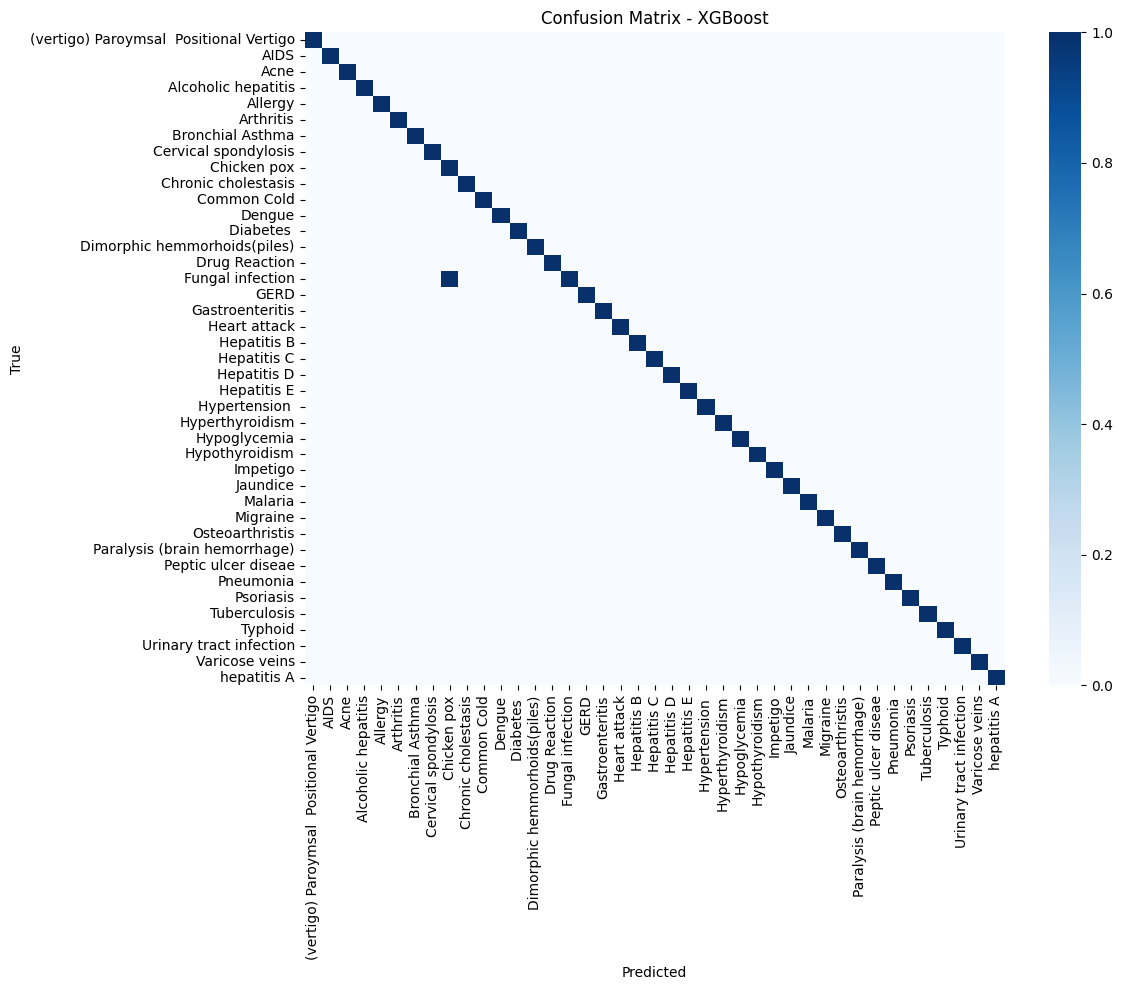

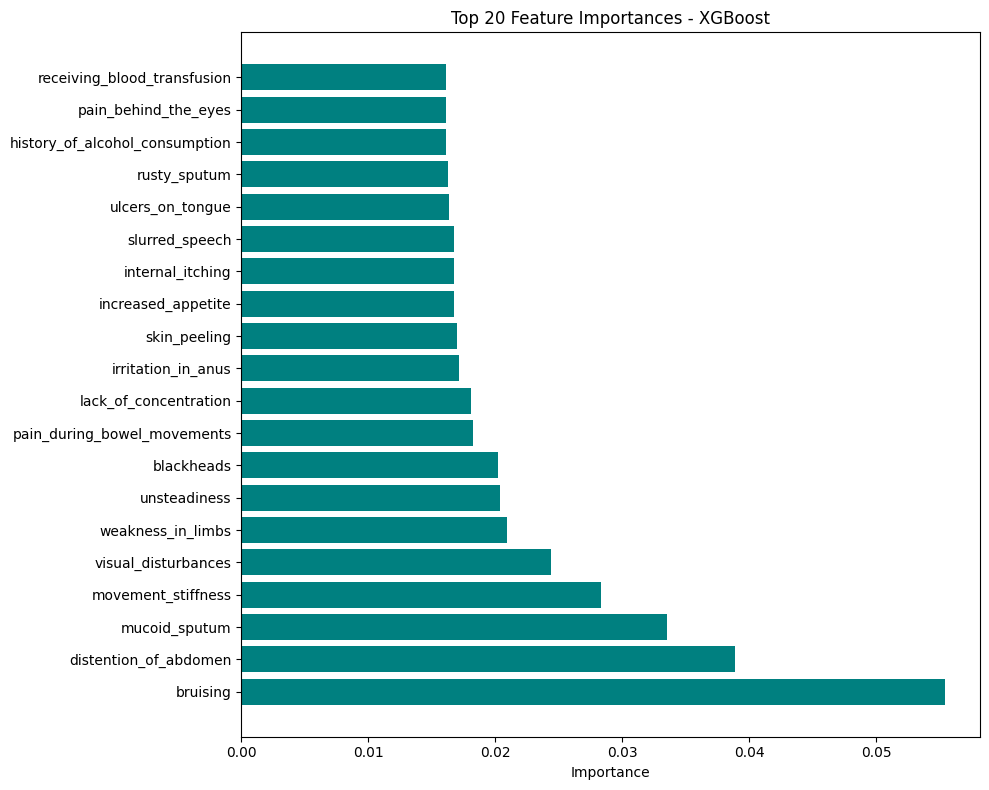


✅ Best traditional model (XGBoost) saved as 'best_traditional_model.pkl'
✅ Label encoder saved as 'label_encoder_traditional.pkl'


In [14]:


# ------------------------------
# 1. Load the exact same splits used for MLP
# ------------------------------
X_train = pd.read_csv('X_train.csv')
X_val = pd.read_csv('X_val.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_val = pd.read_csv('y_val.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)
num_classes = len(le.classes_)

print("="*60)
print("DATA SHAPES (same as MLP)")
print("="*60)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Test set contains {len(X_test)} unique symptom-disease combinations.")
print("="*60)

# ------------------------------
# 2. Train Traditional Models
# ------------------------------

models = {
    'Logistic Regression': LogisticRegression(
        multi_class='multinomial', 
        max_iter=1000, 
        solver='lbfgs',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, 
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        objective='multi:softmax',
        num_class=num_classes,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1
    )
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train
    model.fit(X_train, y_train_enc)
    
    # Predict on validation (for early stopping) and test
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # For AUC-ROC, we need probabilities
    if hasattr(model, 'predict_proba'):
        y_test_probs = model.predict_proba(X_test)
    else:
        y_test_probs = None
    
    # Metrics
    accuracy = accuracy_score(y_test_enc, y_test_pred)
    precision_macro = precision_score(y_test_enc, y_test_pred, average='macro', zero_division=0)
    precision_weighted = precision_score(y_test_enc, y_test_pred, average='weighted', zero_division=0)
    recall_macro = recall_score(y_test_enc, y_test_pred, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test_enc, y_test_pred, average='weighted', zero_division=0)
    f1_macro = f1_score(y_test_enc, y_test_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test_enc, y_test_pred, average='weighted', zero_division=0)
    
    # AUC-ROC (macro) – if probabilities exist
    auc_macro = None
    if y_test_probs is not None:
        try:
            auc_macro = roc_auc_score(
                pd.get_dummies(y_test_enc).values, 
                y_test_probs, 
                multi_class='ovr', 
                average='macro'
            )
        except:
            pass
    
    results[name] = {
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'precision_weighted': precision_weighted,
        'recall_macro': recall_macro,
        'recall_weighted': recall_weighted,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'auc_macro': auc_macro,
        'predictions': y_test_pred,
        'model': model
    }
    
    print(f"  ✓ Done. Test Accuracy: {accuracy:.4f}")

# ------------------------------
# 3. Print Comparison Table
# ------------------------------
print("\n" + "="*60)
print("TRADITIONAL MODELS PERFORMANCE ON TEST SET (vs MLP)")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': [],
    'Accuracy': [],
    'Precision (macro)': [],
    'Recall (macro)': [],
    'F1 (macro)': [],
    'AUC-ROC (macro)': []
})

for name, metrics in results.items():
    comparison_df = pd.concat([comparison_df, pd.DataFrame({
        'Model': [name],
        'Accuracy': [metrics['accuracy']],
        'Precision (macro)': [metrics['precision_macro']],
        'Recall (macro)': [metrics['recall_macro']],
        'F1 (macro)': [metrics['f1_macro']],
        'AUC-ROC (macro)': [metrics['auc_macro'] if metrics['auc_macro'] else 'N/A']
    })], ignore_index=True)

# Add MLP results from your previous run
comparison_df = pd.concat([comparison_df, pd.DataFrame({
    'Model': ['MLP (Deep Learning)'],
    'Accuracy': [0.9762],
    'Precision (macro)': [0.9878],
    'Recall (macro)': [0.9878],
    'F1 (macro)': [0.9837],
    'AUC-ROC (macro)': [0.9936]
})], ignore_index=True)

print(comparison_df.to_string(index=False))

# ------------------------------
# 4. Detailed Classification Report for Best Traditional Model
# ------------------------------
best_model_name = 'XGBoost'  # Usually the best
best_model = results[best_model_name]['model']
best_preds = results[best_model_name]['predictions']

print("\n" + "="*60)
print(f"DETAILED CLASSIFICATION REPORT - {best_model_name}")
print("="*60)
print(classification_report(y_test_enc, best_preds, target_names=le.classes_, digits=4))

# ------------------------------
# 5. Confusion Matrix for Best Model
# ------------------------------
cm = confusion_matrix(y_test_enc, best_preds)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(f'{best_model_name}_confusion_matrix.png')
plt.show()

# ------------------------------
# 6. Feature Importance (for Random Forest & XGBoost)
# ------------------------------
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = X_train.columns.tolist()
    
    # Get top 20 features
    top_idx = np.argsort(importances)[-20:][::-1]
    top_features = [feature_names[i] for i in top_idx]
    top_importances = importances[top_idx]
    
    plt.figure(figsize=(10,8))
    plt.barh(top_features, top_importances, color='teal')
    plt.title(f'Top 20 Feature Importances - {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig(f'{best_model_name}_feature_importance.png')
    plt.show()

# ------------------------------
# 7. Save the Best Traditional Model
# ------------------------------
with open('best_traditional_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
    
with open('label_encoder_traditional.pkl', 'wb') as f:
    pickle.dump(le, f)

print(f"\n✅ Best traditional model ({best_model_name}) saved as 'best_traditional_model.pkl'")
print("✅ Label encoder saved as 'label_encoder_traditional.pkl'")